<a href="https://colab.research.google.com/github/DarshiniMahesh/AI-Practice/blob/main/Dogs%26Cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Setup Kaggle and Download Dataset
# ============================================================
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d tongpython/cat-and-dog

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
cat-and-dog.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# ============================================================
# CELL 2 — Unzip the Dataset
# ============================================================
import zipfile

zip_ref = zipfile.ZipFile('/content/cat-and-dog.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
# ============================================================
# CELL 3 — Import Libraries
# ============================================================
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import (Dense, Conv2D, MaxPooling2D,
                          Flatten, BatchNormalization, Dropout)
import matplotlib.pyplot as plt
import cv2

In [ ]:
# ============================================================
# CELL 4 — Create Training Dataset
# NOTE: Your path has a nested folder — training_set/training_set/
# ============================================================
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/training_set/training_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 8005 files belonging to 2 classes.


In [ ]:
# ============================================================
# CELL 5 — Create Validation Dataset
# NOTE: Your path has a nested folder — test_set/test_set/
# ============================================================
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test_set/test_set',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 2023 files belonging to 2 classes.


In [ ]:
# ============================================================
# CELL 6 — Normalize Pixel Values (0–255 → 0.0–1.0)
# ============================================================
def process(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds     = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
# ============================================================
# CELL 7 — Build the CNN Model
# ============================================================
model = Sequential()

# Input layer
model.add(tf.keras.Input(shape=(256, 256, 3)))

# Conv Block 1
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Conv Block 2
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Conv Block 3
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Fully Connected Classifier
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ============================================================
# CELL 8 — Compile the Model
# ============================================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ============================================================
# CELL 9 — Train the Model (10 Epochs)
# ============================================================
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 123ms/step - accuracy: 0.5558 - loss: 3.1155 - val_accuracy: 0.5012 - val_loss: 3.8308
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.6045 - loss: 0.7342 - val_accuracy: 0.6362 - val_loss: 0.6538
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - accuracy: 0.6601 - loss: 0.6145 - val_accuracy: 0.6490 - val_loss: 0.6503
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.7012 - loss: 0.5706 - val_accuracy: 0.6960 - val_loss: 0.5736
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.7395 - loss: 0.5232 - val_accuracy: 0.6925 - val_loss: 0.6532
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 109ms/step - accuracy: 0.7650 - loss: 0.4803 - val_accuracy: 0.6248 - val_loss: 1.0856
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.8065 - loss: 0.4245 - val_accuracy: 0.7459 - val_loss: 0.5257
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.8364 - loss: 0.360

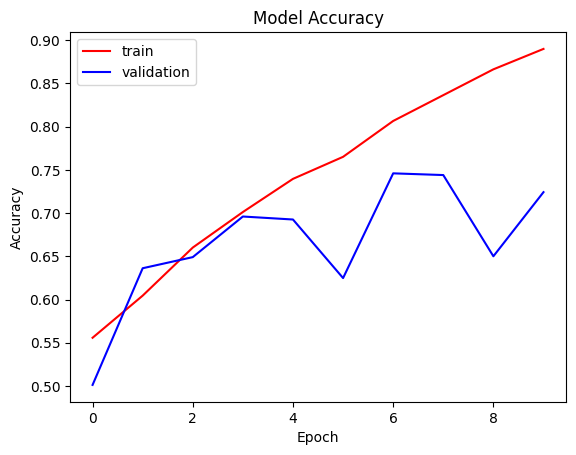

In [ ]:
# ============================================================
# CELL 10 — Plot Accuracy Graph
# ============================================================
plt.plot(history.history['accuracy'],     color='red',  label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

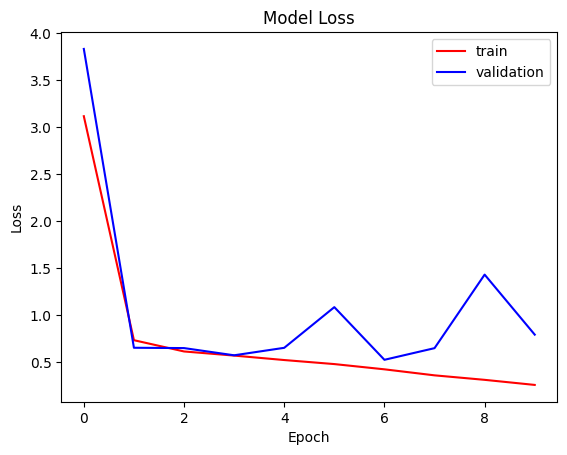

In [ ]:
# ============================================================
# CELL 11 — Plot Loss Graph
# ============================================================
plt.plot(history.history['loss'],     color='red',  label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

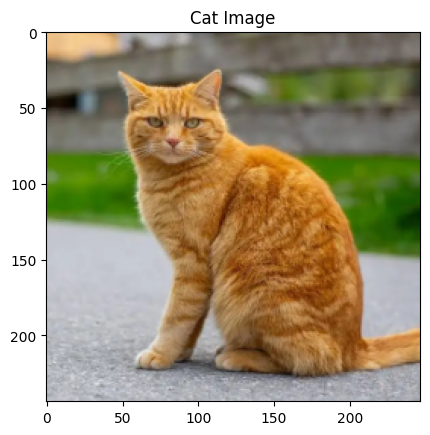

Original shape: (244, 247, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Raw prediction: [[0.99762505]]
Predicted: CAT  (confidence: 0.2%)


In [ ]:
# ============================================================
# CELL 12 — Predict on Cat Image  (FIXED)
# ============================================================
test_img = cv2.imread('/content/cat.png')

# FIX: Convert BGR → RGB to match how the model was trained
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

plt.imshow(test_img)
plt.title('Cat Image')
plt.show()

print("Original shape:", test_img.shape)

test_img_resized = cv2.resize(test_img, (256, 256))
test_input = test_img_resized.reshape((1, 256, 256, 3))
test_input = test_input / 255.0  # normalize

prediction = model.predict(test_input)
print("Raw prediction:", prediction)

if prediction[0][0] > 0.5:
    print("Predicted: CAT  (confidence: {:.1f}%)".format((1 - prediction[0][0]) * 100))
else:
    print("Predicted: DOG  (confidence: {:.1f}%)".format(prediction[0][0] * 100))

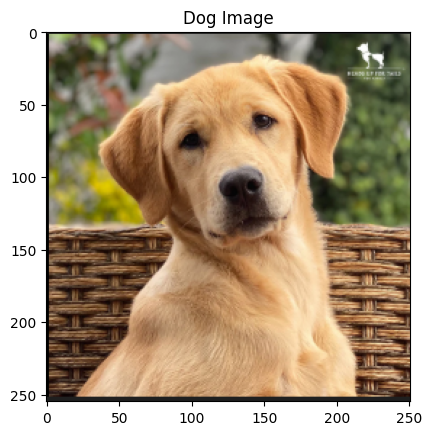

Original shape: (255, 251, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Raw prediction: [[0.98923665]]
Predicted: DOG  (confidence: 98.9%)


In [ ]:
# ============================================================
# CELL 13 — Predict on Dog Image  (FIXED)
# ============================================================
test_img = cv2.imread('/content/dog.png')

# FIX: Convert BGR → RGB to match how the model was trained
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

plt.imshow(test_img)
plt.title('Dog Image')
plt.show()

print("Original shape:", test_img.shape)

test_img_resized = cv2.resize(test_img, (256, 256))
test_input = test_img_resized.reshape((1, 256, 256, 3))
test_input = test_input / 255.0  # normalize

prediction = model.predict(test_input)
print("Raw prediction:", prediction)

if prediction[0][0] < 0.5:
    print("Predicted: CAT  (confidence: {:.1f}%)".format((1 - prediction[0][0]) * 100))
else:
    print("Predicted: DOG  (confidence: {:.1f}%)".format(prediction[0][0] * 100))

In [ ]:
! pip install gradio -q

In [ ]:
import gradio as gr
import numpy as np
import cv2

# Prediction function
def predict_image(img):
    # Convert PIL → numpy
    img = np.array(img)

    # Resize
    img = cv2.resize(img, (256,256))

    # Normalize
    img = img / 255.0

    # Reshape
    img = img.reshape((1,256,256,3))

    # Predict
    pred = model.predict(img)[0][0]

    if pred > 0.5:
        return f"Dog 🐶 ({pred:.2f})"
    else:
        return f"Cat 🐱 ({1-pred:.2f})"

In [ ]:
interface = gr.Interface(
    fn=predict_image,

    inputs=gr.Image(type="pil", label="Upload Dog/Cat Image"),

    outputs=gr.Textbox(label="Prediction Result"),

    title="🐶🐱 Dog vs Cat Classifier",

    description="Upload an image and the model will predict whether it is a Dog or a Cat.",

    theme="soft"
)

interface.launch()